# HW 2 Problem 2: Shades of NULL

# Import Libraries

In [1]:
#@markdown Install Libraries
!pip install virny
!pip install fairlearn
!git clone https://github.com/FalaahArifKhan/data-cleaning-stability.git
!mv /content/data-cleaning-stability /content/data_cleaning_stability

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
Cloning into 'data-cleaning-stability'...
remote: Enumerating objects: 8730, done.
remote: Counting objects: 100% (867/867), done.
remote: Compressing objects: 100% (307/307), done.
remote: Total 8730 (delta 588), reused 573 (delta 560), pack-reused 7863 (from 2)
Receiving objects: 100% (8730/8730), 37.90 MiB | 16.39 MiB/s, done.
Resolving deltas: 100% (6859/6859), done.
Updating files: 100% (331/331), done.


In [2]:
#@markdown Import statments
import sys
import os
import warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import matplotlib.pyplot as plt
from virny.datasets import LawSchoolDataset
from virny.preprocessing.basic_preprocessing import preprocess_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)

sys.path.append('/content/data_cleaning_stability')
from source.error_injectors import nulls_injector

# Load Data

The Law school dataset (Wightman, 1998) was conducted by a Law School Admission Council (LSAC) survey across 163 law schools in the United States in 1991. The dataset contains the law school admission records. The prediction task is to predict whether a candidate would pass the bar exam or predict a student’s first-year average grade (FYA).

Dataset characteristics: The dataset contains information of 20,798 students characterized by 12 attributes (3 categorical, 3 binary and 6 numerical attributes).

For more information about the dataset, and if you are interested in other datasets, check this [paper](https://arxiv.org/pdf/2110.00530).

In [3]:
#@markdown Set Seeds
DATASET_SPLIT_SEED = 100
MODEL_SEED = 100
TEST_SET_FRACTION = 0.2

In [4]:
#@markdown Load Data
data_loader = LawSchoolDataset()
df = data_loader.full_df
df.head()

,decile1b,decile3,lsat,ugpa,zfygpa,zgpa,fulltime,fam_inc,male,tier,race,pass_bar
0,10.0,10.0,44.0,3.5,1.33,1.88,1,5,0,4,White,1
1,5.0,4.0,29.0,3.5,-0.11,-0.57,1,4,0,2,White,1
2,8.0,7.0,37.0,3.4,0.63,0.37,1,3,1,4,White,1
3,8.0,7.0,43.0,3.3,0.67,0.34,1,4,0,4,White,1
4,3.0,2.0,41.0,3.3,-0.67,-1.30,1,4,0,5,White,1


In [5]:
df.describe()

,decile1b,decile3,lsat,ugpa,zfygpa,zgpa,pass_bar
count,20798.000000,20798.000000,20798.000000,20798.000000,20798.000000,20798.000000,20798.000000
mean,5.562987,5.565054,36.762737,3.226810,0.097801,0.024189,0.889749
std,2.857880,2.857732,5.387053,0.411421,0.929575,0.988012,0.313210
min,1.000000,1.000000,11.000000,1.500000,-3.350000,-6.440000,0.000000
25%,3.000000,3.000000,33.000000,3.000000,-0.550000,-0.670000,1.000000
50%,6.000000,6.000000,37.000000,3.300000,0.090000,0.020000,1.000000
75%,8.000000,8.000000,41.000000,3.500000,0.750000,0.710000,1.000000
max,10.000000,10.000000,48.000000,4.000000,3.480000,4.010000,1.000000


In [6]:
#@markdown Check for Categorical Variables
for col in data_loader.categorical_columns:
    print(f'{col}: {len(data_loader.full_df[col].unique())}')

fulltime: 2
fam_inc: 5
male: 2
tier: 6
race: 2


In [7]:
#@markdown Prediction Target
data_loader.target

'pass_bar'

## Assess Fairness in the original data
In this section, we want to check the original proportions of the data, and also measure how a Random Forest Classifier performs in terms of fairness and accuracy.

In [8]:
#@markdown Race Proportions for bar passing
df.groupby('race')['pass_bar'].value_counts(normalize=True)

race       pass_bar
Non-White  1           0.723012
           0           0.276988
White      1           0.921274
           0           0.078726
Name: proportion, dtype: float64

In [9]:
#@markdown Functions for Fairness Metrics
# metrics for metricframe
metrics = {'accuracy': accuracy_score,
           'precision': precision_score,
           'recall': recall_score,
           'FNR': false_negative_rate,
           'FPR': false_positive_rate,
           }

# fairness metric funciton as dataframe
def fairness_metrics(y_test, y_pred, sensitive_feature):
  fnr_diff = false_negative_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)
  fpr_diff = false_positive_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)
  demo_parity_ratio = demographic_parity_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
  equal_odds_ratio = equalized_odds_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
  selec_rate_diff = selection_rate_difference(y_test, y_pred, sensitive_features=sensitive_feature)

  data = {'fnr_diff': [fnr_diff],
          'fpr_diff': [fpr_diff],
          'demo_parity_ratio': [demo_parity_ratio],
          'equal_odds_ratio': [equal_odds_ratio],
          'selec_rate_diff': [selec_rate_diff]
          }

  df = pd.DataFrame(data)

  return df

In [10]:
#@markdown Function for data processing for Train/Eval
def prepare_data(df, test_size, seed):
  df = df.rename(columns={'race':'Non-White'})
  df['Non-White'] = df['Non-White'].replace({'White':0, 'Non-White':1})
  X = df.iloc[:,:-1]
  y = df[['pass_bar']]
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data(df, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

In [14]:
#@markdown Run Prediction and output fairness metrics
# TODO
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=MODEL_SEED)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
race = X_test['Non-White']

group_by_race = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race
)

print('Fairness metrics for race')
print(group_by_race.by_group)
print('-'*80)
print(fairness_metrics(y_test, y_pred, race))

Fairness metrics for race
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.922856   0.931226  0.989428  0.010572  0.867159
1          0.772660   0.819444  0.869474  0.130526  0.459596
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.119954  0.407563           0.764227          0.530002          0.23104


## Simulate NULLs
Here, we will be using the following [Null Injector](https://github.com/FalaahArifKhan/data-cleaning-stability/blob/main/source/error_injectors/nulls_injector.py)

Make sure you go over the code above to properly simulate the nulls in the dataset.

### 2.1_a We start by simulating MCAR
Missing Completely at Random (MCAR). In law school dataset
with individual law school performance, MCAR holds if data is missing
due to administrative errors, unrelated to the any variables itself. That is: 𝑃(𝑅|𝑋)= 𝑃(𝑅)

In [15]:
#@markdown Inject MCAR Null values using nulls_injector

seed = 42
cols = ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'zgpa']
null_percentage = 0.5

mcar_injector = nulls_injector.NullsInjector(seed=seed,
                                             strategy='MCAR', # strategy should be from the list ['MCAR', 'MAR', 'MNAR']
                                             columns_with_nulls=cols,
                                             null_percentage=null_percentage)

mcar_df = data_loader.full_df.copy()
mcar_df = mcar_injector.fit_transform(mcar_df)
mcar_df.isnull().sum()

,0
decile1b,1730
decile3,1708
lsat,1678
ugpa,1815
zfygpa,1763
zgpa,1705
fulltime,0
fam_inc,0
male,0
tier,0


### 2.1_b How Null Handling changes the fairness for MCAR
Implement two methods of null handling, a median imputation and droping rows.

In [29]:
#@markdown functions to handle nulls
def drop_nulls(df):
    mask = df.notnull().all(axis=1)
    return df[mask]

import numpy as np

def median_impute(X_train, X_test):
    X_train_imp = X_train.copy()
    X_test_imp = X_test.copy()

    numeric_cols = X_train.select_dtypes(include=np.number).columns

    medians = X_train[numeric_cols].median()

    X_train_imp[numeric_cols] = X_train_imp[numeric_cols].fillna(medians)
    X_test_imp[numeric_cols] = X_test_imp[numeric_cols].fillna(medians)

    return X_train_imp, X_test_imp

In [20]:
#@markdown handle nulls
mcar_df_drop = drop_nulls(mcar_df)


In [21]:
#@markdown check for null counts
mcar_df_drop.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [23]:
mcar_drop_X_train, mcar_drop_X_test, mcar_drop_y_train, mcar_drop_y_test = prepare_data(mcar_df_drop, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

mcar_drop_rf = RandomForestClassifier(random_state=MODEL_SEED)
mcar_drop_rf.fit(mcar_drop_X_train, mcar_drop_y_train)
y_pred = mcar_drop_rf.predict(mcar_drop_X_test)
race = mcar_drop_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mcar_drop_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

In [24]:
#@markdown Checking Fairness Metrics after null values handling

print('Fairness metrics for race - MCAR drop nulls')
print('-'*80)
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mcar_drop_y_test, y_pred, race))

Fairness metrics for race - MCAR drop nulls
--------------------------------------------------------------------------------
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.915621   0.934388  0.977928  0.022072  0.910569
1          0.760736   0.825911  0.853556  0.146444  0.494253
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.124371  0.416316            0.77853          0.542796         0.215535


In [26]:
#@markdown split before median
mcar_X_train, mcar_X_test, mcar_y_train, mcar_y_test = prepare_data(mcar_df, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

In [30]:
#@markdown impute by median using train data only!
mcar_median_X_train, mcar_median_X_test = median_impute(mcar_X_train, mcar_X_test)

In [32]:
#@markdown check for null counts
mcar_median_X_train.isnull().sum()
mcar_median_X_test.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [33]:
mcar_median_rf = RandomForestClassifier(random_state=MODEL_SEED)
mcar_median_rf.fit(mcar_median_X_train, mcar_y_train)
y_pred = mcar_median_rf.predict(mcar_median_X_test)
race = mcar_median_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mcar_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

In [34]:
#@markdown Checking Fairness Metrics after null values handling

print('Fairness metrics for race - MCAR median Imputed')
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mcar_y_test, y_pred, race))

Fairness metrics for race - MCAR median Imputed
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.925437   0.930904  0.992848  0.007152  0.874539
1          0.750371   0.803960  0.854737  0.145263  0.500000
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.138111  0.374539           0.762841           0.57173         0.233282


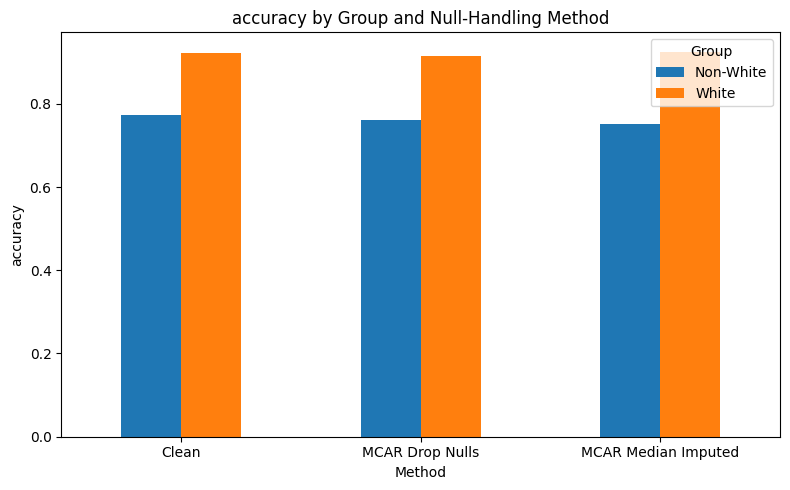

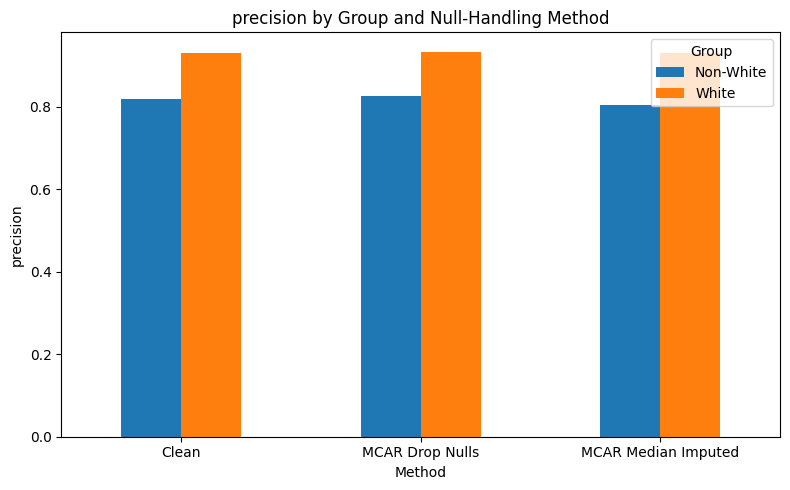

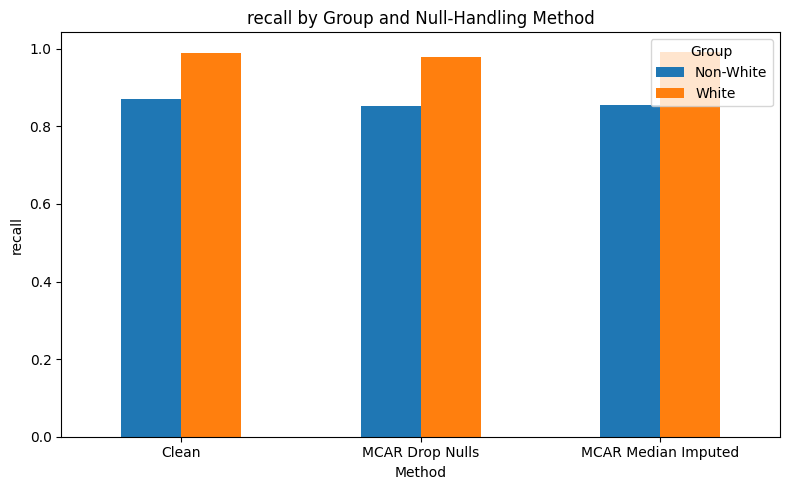

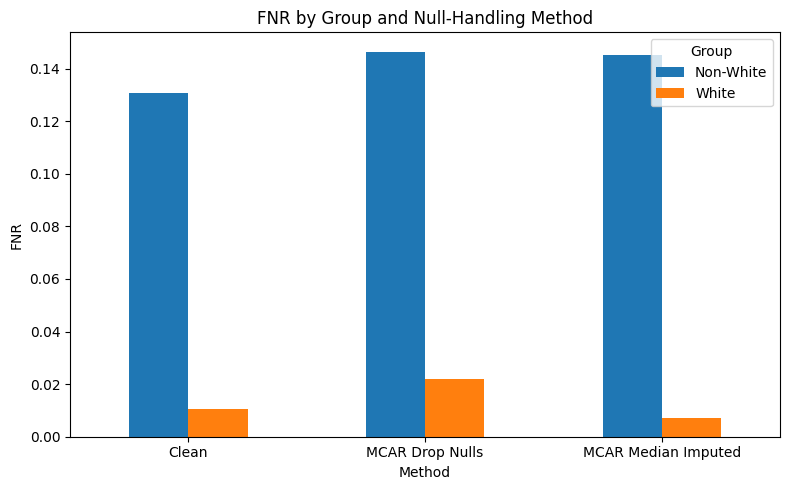

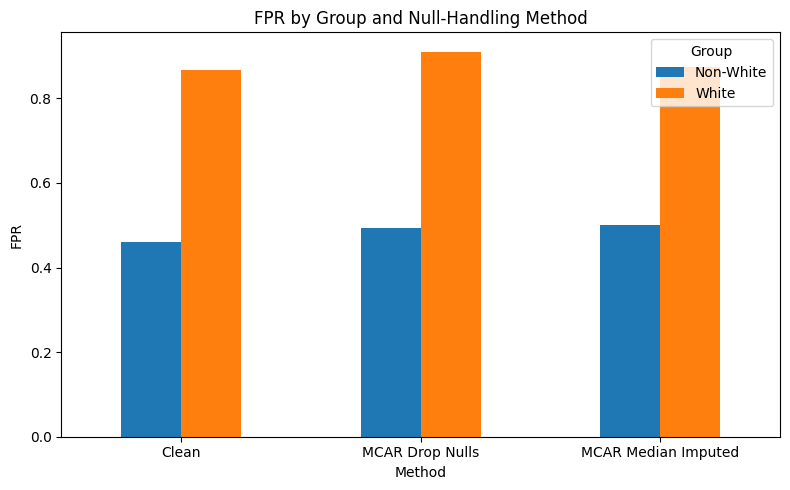

In [36]:
import matplotlib.pyplot as plt

group_metrics = pd.DataFrame({
    'Method': ['Clean', 'Clean', 'MCAR Median Imputed', 'MCAR Median Imputed', 'MCAR Drop Nulls', 'MCAR Drop Nulls'],
    'Group': ['White', 'Non-White', 'White', 'Non-White', 'White', 'Non-White'],
    'accuracy': [0.922856, 0.772660, 0.925437, 0.750371, 0.915621, 0.760736],
    'precision': [0.931226, 0.819444, 0.930904, 0.803960, 0.934388, 0.825911],
    'recall': [0.989428, 0.869474, 0.992848, 0.854737, 0.977928, 0.853556],
    'FNR': [0.010572, 0.130526, 0.007152, 0.145263, 0.022072, 0.146444],
    'FPR': [0.867159, 0.459596, 0.874539, 0.500000, 0.910569, 0.494253]
})

fairness_summary = pd.DataFrame({
    'Method': ['Clean', 'MCAR Median Imputed', 'MCAR Drop Nulls'],
    'fnr_diff': [0.119954, 0.138111, 0.124371],
    'fpr_diff': [0.407563, 0.374539, 0.416316],
    'demographic_parity_ratio': [0.764227, 0.762841, 0.77853],
    'equal_odds_ratio': [0.530002, 0.57173, 0.542796],
    'selection_rate_diff': [0.23104, 0.233282, 0.215535]
})


metrics_to_plot = ['accuracy', 'precision', 'recall', 'FNR', 'FPR']

for metric in metrics_to_plot:
    pivot_df = group_metrics.pivot(index='Method', columns='Group', values=metric)

    ax = pivot_df.plot(kind='bar', figsize=(8, 5))
    ax.set_title(f'{metric} by Group and Null-Handling Method')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.legend(title='Group')
    plt.tight_layout()
    plt.show()



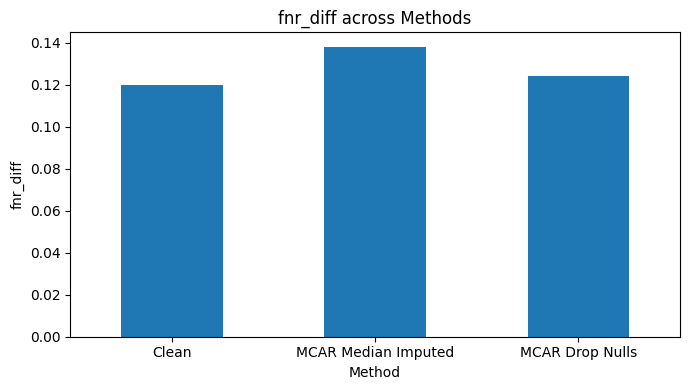

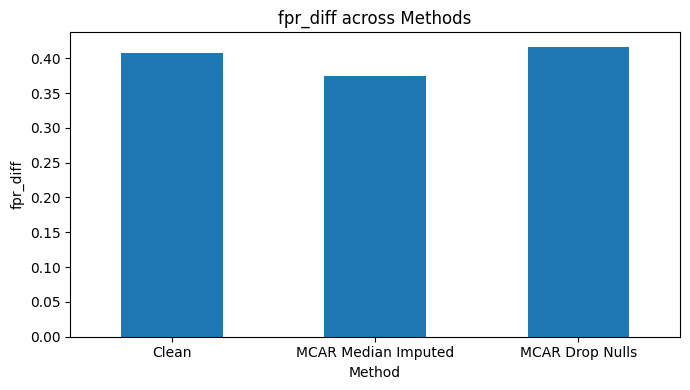

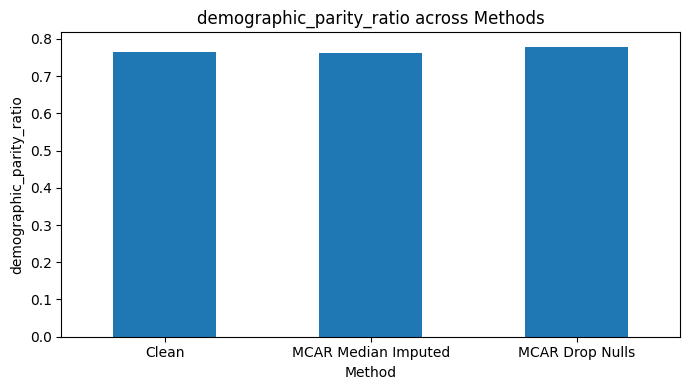

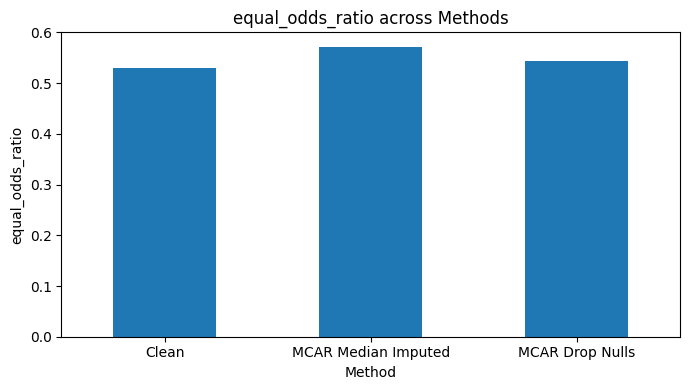

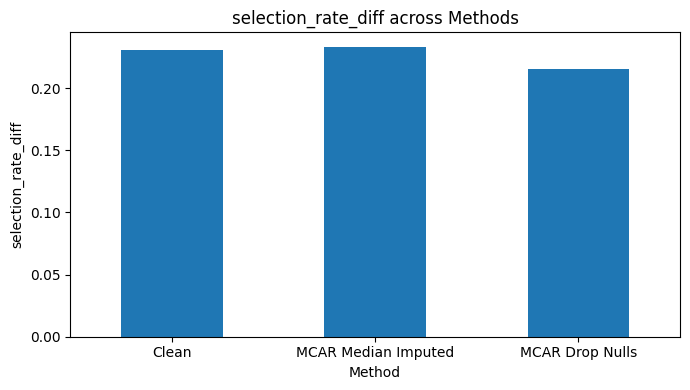

In [37]:
disparity_metrics = [
    'fnr_diff',
    'fpr_diff',
    'demographic_parity_ratio',
    'equal_odds_ratio',
    'selection_rate_diff'
]

for metric in disparity_metrics:
    ax = fairness_summary.plot(
        x='Method',
        y=metric,
        kind='bar',
        figsize=(7, 4),
        legend=False
    )
    ax.set_title(f'{metric} across Methods')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

### 2.2_a Simulating MAR
Missing at Random (MAR). If the disadvantaged group are more likely to withhold their law school performance, and this can be explained by observed covariates (i.e., race), then MAR holds. Here, missingness depends only on observed features, not the missing values themselves: 𝑃(𝑅|𝑋)= 𝑃(𝑅|𝑋obs).

In [47]:
#@markdown TODO: inject MAR conditioned on Non-white students
#@markdown Hint: add a condition input to NullsInjector. condition has to be tuple of conditions, like ('col_name', value)
seed = 42
cols = ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'zgpa']
null_percentage = 0.5

mar_injector = nulls_injector.NullsInjector(seed=seed, strategy = "MAR", columns_with_nulls = cols, null_percentage=null_percentage, condition=("race", 'Non-White'))

In [48]:
mar_df = data_loader.full_df.copy()
mar_df = mar_injector.fit_transform(mar_df)
mar_df.isnull().sum()

,0
decile1b,279
decile3,260
lsat,296
ugpa,260
zfygpa,288
zgpa,270
fulltime,0
fam_inc,0
male,0
tier,0


### 2.2_b How Null Handling changes the fairness for MAR
We implement two methods of null handling, a median imputation and droping rows.



In [49]:
#TODO: handle null values
mar_df_drop = drop_nulls(mar_df)
mar_df_drop.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [53]:
#TODO: run a prediction and fairness metric evaluation for dropping rows

mar_drop_X_train, mar_drop_X_test, mar_drop_y_train, mar_drop_y_test = prepare_data(mar_df_drop, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

mar_drop_rf = RandomForestClassifier(random_state=MODEL_SEED)
mar_drop_rf.fit(mar_drop_X_train, mar_drop_y_train)
y_pred = mar_drop_rf.predict(mar_drop_X_test)
race = mar_drop_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mar_drop_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

print('Fairness metrics for race - MAR drop nulls')
print('-'*80)
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mar_drop_y_test, y_pred, race))

Fairness metrics for race - MAR drop nulls
--------------------------------------------------------------------------------
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.918525   0.930873  0.984816  0.015184  0.870849
1          0.764350   0.818930  0.854077  0.145923  0.448980
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.130738  0.421869           0.752202          0.515566         0.241847


In [55]:
#TODO: run a prediction and fairness metric evaluation for median imputation (using train data only)

mar_X_train, mar_X_test, mar_y_train, mar_y_test = prepare_data(mar_df, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

mar_median_X_train, mar_median_X_test = median_impute(mar_X_train, mar_X_test)
mar_median_X_train.isnull().sum()
mar_median_X_test.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [56]:
mar_median_rf = RandomForestClassifier(random_state=MODEL_SEED)
mar_median_rf.fit(mar_median_X_train, mar_y_train)
y_pred = mar_median_rf.predict(mar_median_X_test)
race = mar_median_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mar_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

print('Fairness metrics for race - MAR median Imputed')
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mar_y_test, y_pred, race))

Fairness metrics for race - MAR median Imputed
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.923717   0.931539  0.990050  0.009950  0.863469
1          0.745914   0.806452  0.842105  0.157895  0.484848
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.147944   0.37862           0.751876          0.561513         0.243214


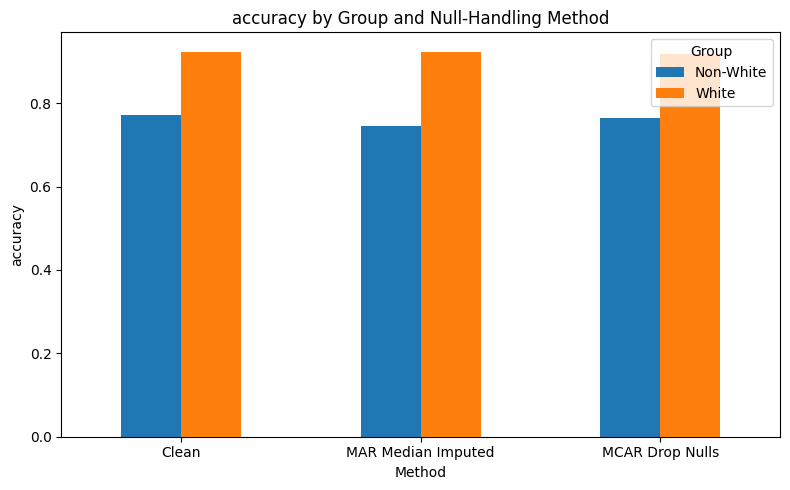

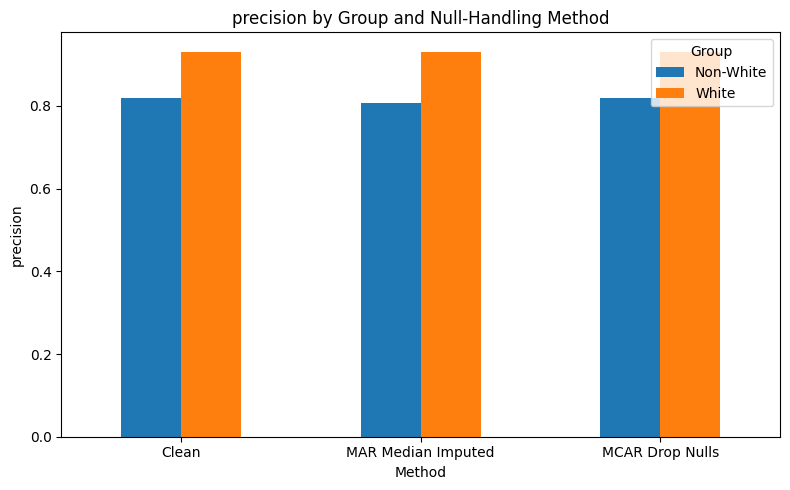

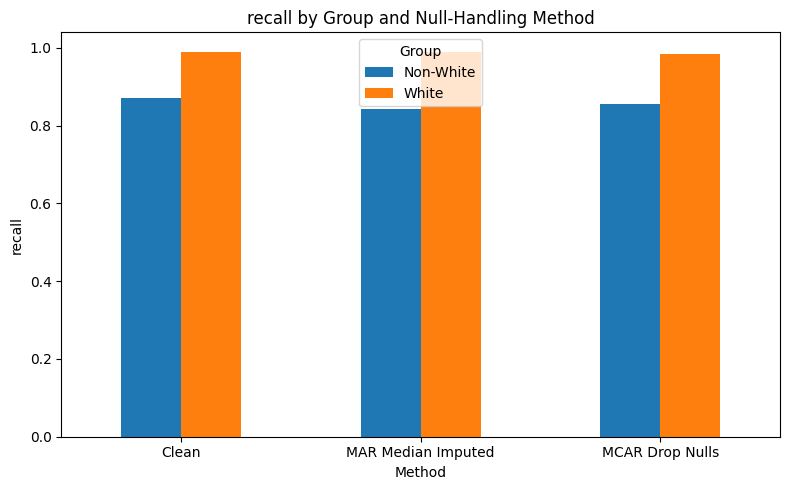

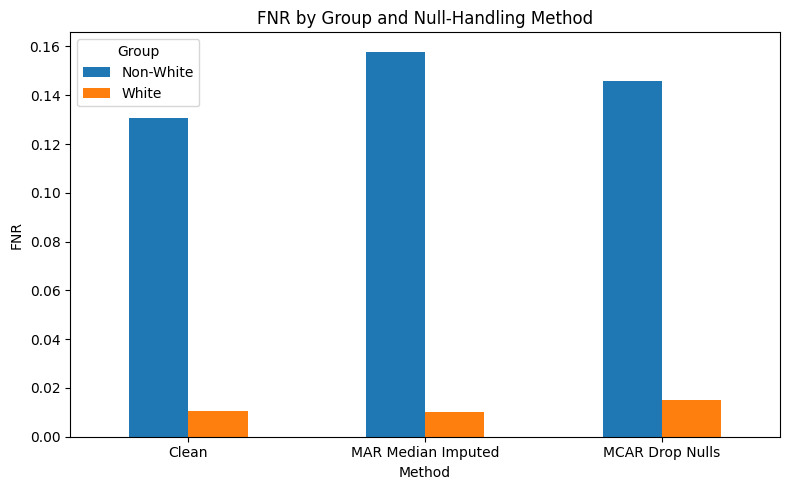

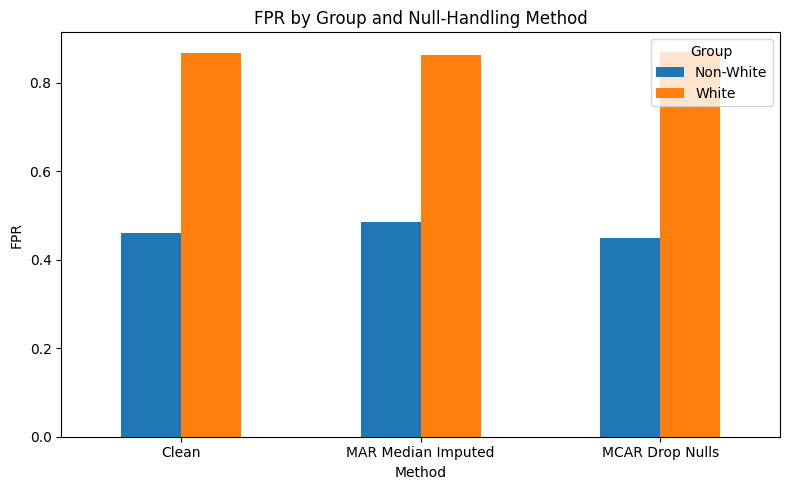

In [57]:
group_metrics = pd.DataFrame({
    'Method': ['Clean', 'Clean', 'MAR Median Imputed', 'MAR Median Imputed', 'MCAR Drop Nulls', 'MCAR Drop Nulls'],
    'Group': ['White', 'Non-White', 'White', 'Non-White', 'White', 'Non-White'],
    'accuracy': [0.922856, 0.772660, 0.923717, 0.745914, 0.918525, 0.764350],
    'precision': [0.931226, 0.819444, 0.931539, 0.806452, 0.930873, 0.818930],
    'recall': [0.989428, 0.869474, 0.990050, 0.842105, 0.984816, 0.854077],
    'FNR': [0.010572, 0.130526, 0.009950, 0.157895, 0.015184, 0.145923],
    'FPR': [0.867159, 0.459596, 0.863469, 0.484848, 0.870849, 0.448980]
})

fairness_summary = pd.DataFrame({
    'Method': ['Clean', 'MAR Median Imputed', 'MAR Drop Nulls'],
    'fnr_diff': [0.119954, 0.147944, 0.130738],
    'fpr_diff': [0.407563, 0.37862, 0.421869],
    'demographic_parity_ratio': [0.764227, 0.751876, 0.752202],
    'equal_odds_ratio': [0.530002, 0.561513, 0.515566],
    'selection_rate_diff': [0.23104, 0.243214, 0.241847]
})

metrics_to_plot = ['accuracy', 'precision', 'recall', 'FNR', 'FPR']

for metric in metrics_to_plot:
    pivot_df = group_metrics.pivot(index='Method', columns='Group', values=metric)

    ax = pivot_df.plot(kind='bar', figsize=(8, 5))
    ax.set_title(f'{metric} by Group and Null-Handling Method')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.legend(title='Group')
    plt.tight_layout()
    plt.show()


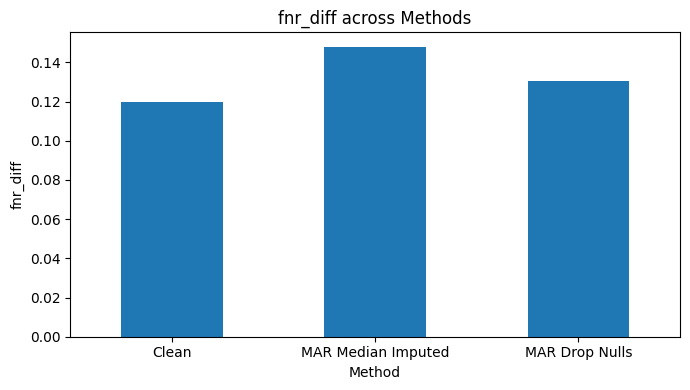

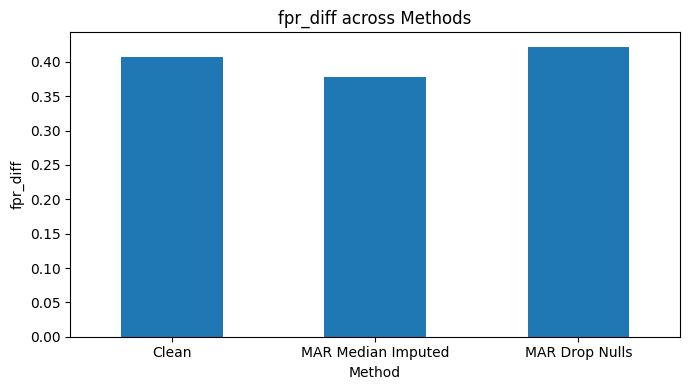

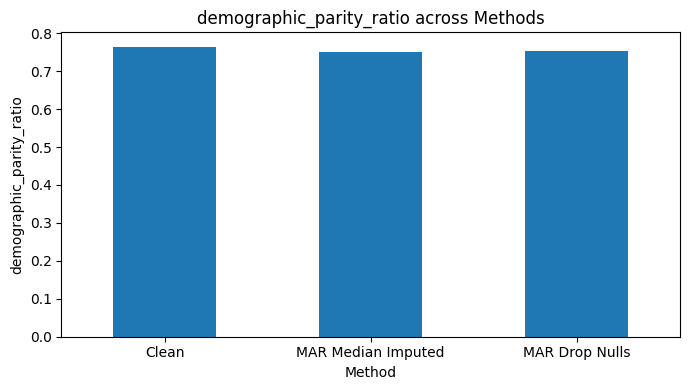

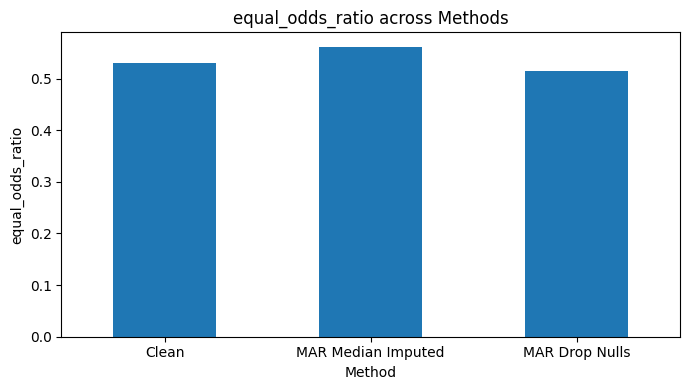

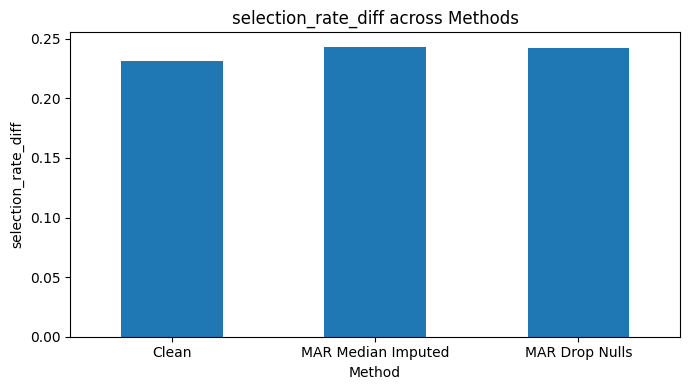

In [58]:
disparity_metrics = [
    'fnr_diff',
    'fpr_diff',
    'demographic_parity_ratio',
    'equal_odds_ratio',
    'selection_rate_diff'
]

for metric in disparity_metrics:
    ax = fairness_summary.plot(
        x='Method',
        y=metric,
        kind='bar',
        figsize=(7, 4),
        legend=False
    )
    ax.set_title(f'{metric} across Methods')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

### 2.3_a Simulating Missing not at Random
Missing Not at Random (MNAR). Consider a student whose
academic performance depends by different law schools (i.e. different schools have different grading standards)—not captured in the data—rather than by race. Suppose students with lower academic performance are more likely to withhold this information. In this case, MNAR holds because missingness is correlated with the missing value itself and can not be explained by observed covariates (i.e., race): 𝑃(𝑅|𝑋) ≠ 𝑃(𝑅|𝑋obs)

In [73]:
#@markdown TODO: select columns you want to simulate MNAR, and simulate MNAR.
#@markdown hint: condition value has to be a conditional statement, like (col, {'lt': col.median()}).
#@markdown Options for condition are 'ge'(greater or eqal to), 'gt'(greater than), 'le' (less or equal to), 'lt'(less than))
null_percentage = 0.5
seed = 42

mnar_df = data_loader.full_df.copy()
cols = ["ugpa", "zfygpa", "zgpa"]
for col in cols:
  mnar_injector = nulls_injector.NullsInjector(columns_with_nulls=[col], condition=(col,{'lt':mnar_df[col].median()}),
                                               seed=seed, strategy = "MNAR", null_percentage=null_percentage)
  mnar_df = mnar_injector.fit_transform(mnar_df)

mnar_df.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,5175
zfygpa,5189
zgpa,5194
fulltime,0
fam_inc,0
male,0
tier,0


### 2.3_b How Null Handling changes the fairness for MNAR
We implement two methods of null handling, a median imputation and droping rows.



In [74]:
#@TODO: handle null values
mnar_df_drop = drop_nulls(mnar_df)
mnar_df_drop.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [75]:
#@TODO: run a prediction and fairness metric evaluation for dropping rows

mnar_drop_X_train, mnar_drop_X_test, mnar_drop_y_train, mnar_drop_y_test = prepare_data(mnar_df_drop, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

mnar_drop_rf = RandomForestClassifier(random_state=MODEL_SEED)
mnar_drop_rf.fit(mnar_drop_X_train, mnar_drop_y_train)
y_pred = mnar_drop_rf.predict(mnar_drop_X_test)
race = mnar_drop_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mnar_drop_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

print('Fairness metrics for race - MNAR drop nulls')
print('-'*80)
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mnar_drop_y_test, y_pred, race))

Fairness metrics for race - MNAR drop nulls
--------------------------------------------------------------------------------
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.961366   0.966685  0.994193  0.005807  0.921875
1          0.854749   0.886076  0.945946  0.054054  0.580645
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.048247   0.34123           0.890158          0.629852          0.10892


In [76]:
#@TODO: run a prediction and fairness metric evaluation for median imputation (using train data only)
mnar_X_train, mnar_X_test, mnar_y_train, mnar_y_test = prepare_data(mnar_df, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

mnar_median_X_train, mnar_median_X_test = median_impute(mnar_X_train, mnar_X_test)
mnar_median_X_train.isnull().sum()
mnar_median_X_test.isnull().sum()

,0
decile1b,0
decile3,0
lsat,0
ugpa,0
zfygpa,0
zgpa,0
fulltime,0
fam_inc,0
male,0
tier,0


In [77]:
mnar_median_rf = RandomForestClassifier(random_state=MODEL_SEED)
mnar_median_rf.fit(mnar_median_X_train, mnar_y_train)
y_pred = mnar_median_rf.predict(mnar_median_X_test)
race = mnar_median_X_test['Non-White']

groupby_race = MetricFrame(
    metrics=metrics,
    y_true=mnar_y_test,
    y_pred=y_pred,
    sensitive_features=race
)

print('Fairness metrics for race - MNAR median Imputed')
print(groupby_race.by_group)
print('-'*80)
print(fairness_metrics(mnar_y_test, y_pred, race))

Fairness metrics for race - MNAR median Imputed
           accuracy  precision    recall       FNR       FPR
Non-White                                                   
0          0.919128   0.929701  0.986940  0.013060  0.885609
1          0.756315   0.807921  0.858947  0.141053  0.489899
--------------------------------------------------------------------------------
   fnr_diff  fpr_diff  demo_parity_ratio  equal_odds_ratio  selec_rate_diff
0  0.127993   0.39571           0.766416          0.553178         0.228694


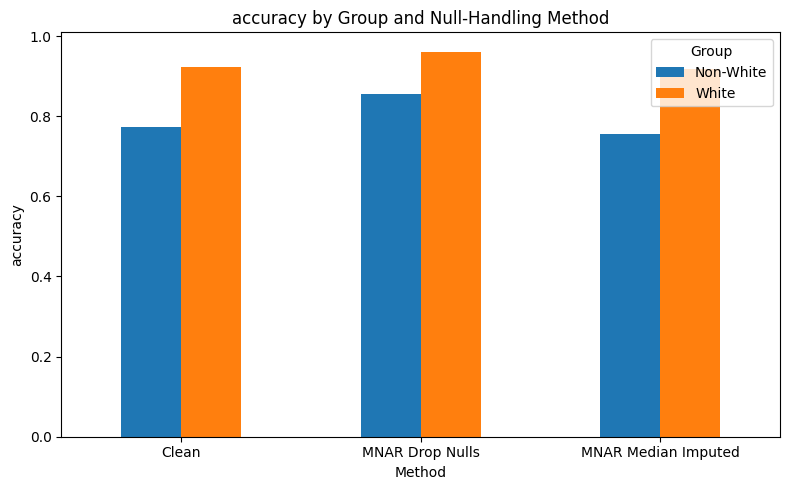

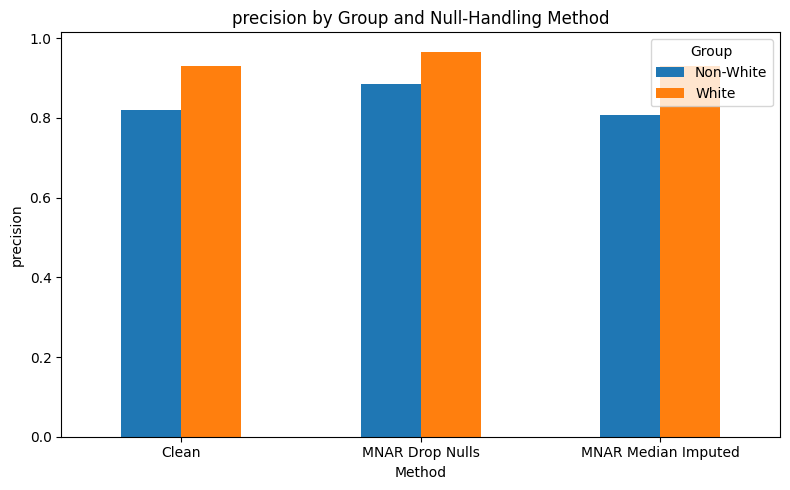

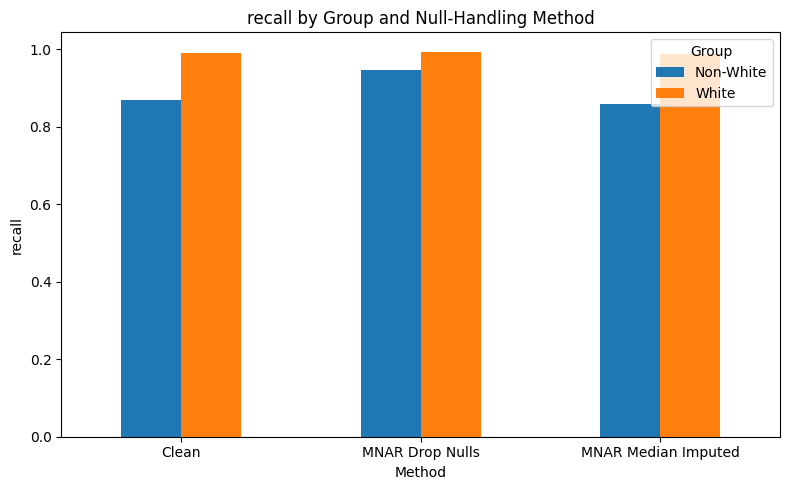

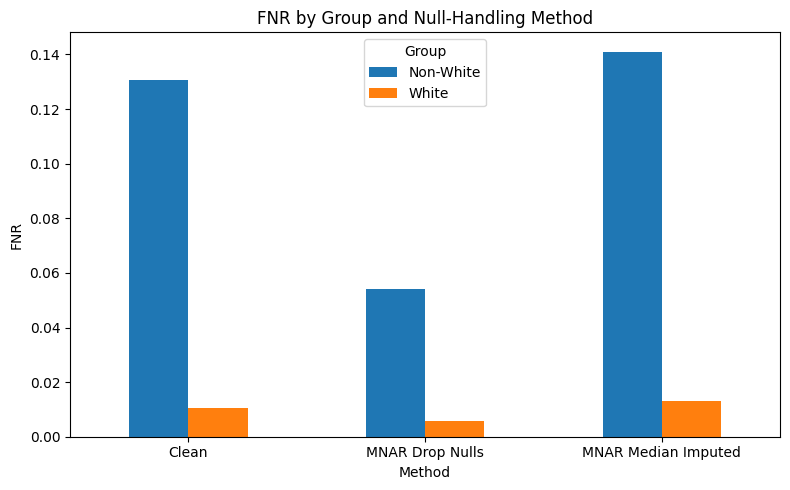

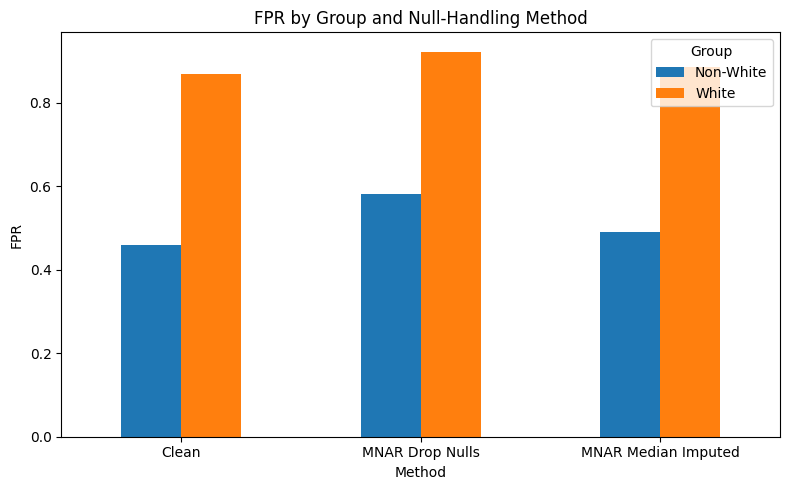

In [78]:
group_metrics = pd.DataFrame({
    'Method': ['Clean', 'Clean',
               'MNAR Median Imputed', 'MNAR Median Imputed',
               'MNAR Drop Nulls', 'MNAR Drop Nulls'],

    'Group': ['White', 'Non-White',
              'White', 'Non-White',
              'White', 'Non-White'],

    'accuracy': [0.922856, 0.772660,
                 0.919128, 0.756315,
                 0.961366, 0.854749],

    'precision': [0.931226, 0.819444,
                  0.929701, 0.807921,
                  0.966685, 0.886076],

    'recall': [0.989428, 0.869474,
               0.986940, 0.858947,
               0.994193, 0.945946],

    'FNR': [0.010572, 0.130526,
            0.013060, 0.141053,
            0.005807, 0.054054],

    'FPR': [0.867159, 0.459596,
            0.885609, 0.489899,
            0.921875, 0.580645]
})

fairness_summary = pd.DataFrame({
    'Method': ['Clean', 'MNAR Median Imputed', 'MNAR Drop Nulls'],

    'fnr_diff': [0.119954, 0.127993, 0.048247],

    'fpr_diff': [0.407563, 0.39571, 0.34123],

    'demographic_parity_ratio': [0.764227, 0.766416, 0.890158],

    'equal_odds_ratio': [0.530002, 0.553178, 0.629852],

    'selection_rate_diff': [0.23104, 0.228694, 0.10892]
})

metrics_to_plot = ['accuracy', 'precision', 'recall', 'FNR', 'FPR']

for metric in metrics_to_plot:
    pivot_df = group_metrics.pivot(index='Method', columns='Group', values=metric)

    ax = pivot_df.plot(kind='bar', figsize=(8, 5))
    ax.set_title(f'{metric} by Group and Null-Handling Method')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.legend(title='Group')
    plt.tight_layout()
    plt.show()


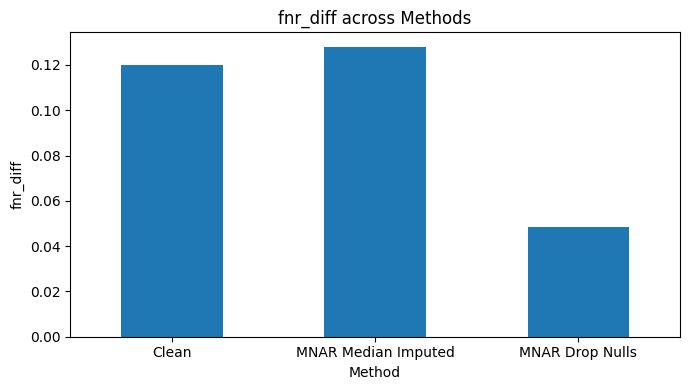

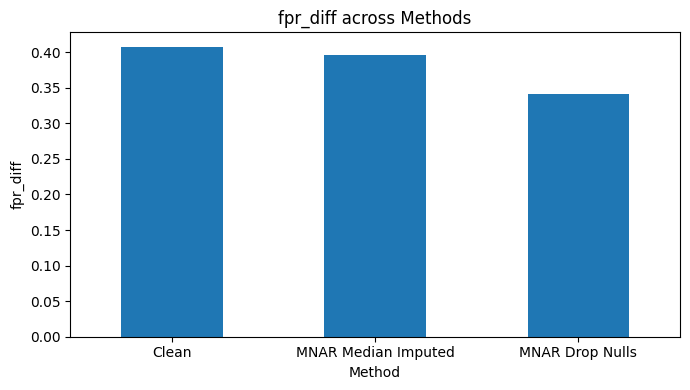

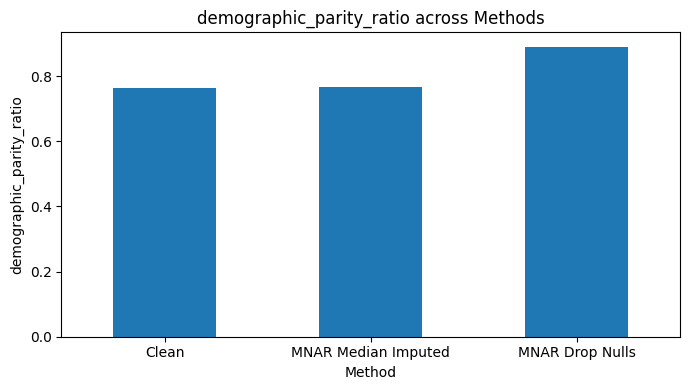

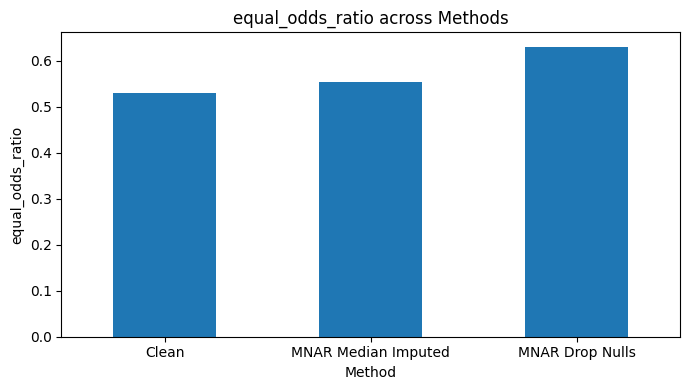

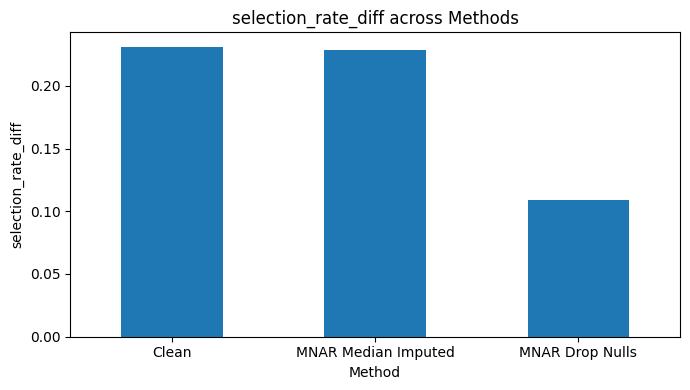

In [79]:
disparity_metrics = [
    'fnr_diff',
    'fpr_diff',
    'demographic_parity_ratio',
    'equal_odds_ratio',
    'selection_rate_diff'
]

for metric in disparity_metrics:
    ax = fairness_summary.plot(
        x='Method',
        y=metric,
        kind='bar',
        figsize=(7, 4),
        legend=False
    )
    ax.set_title(f'{metric} across Methods')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

### 2.4 D-Hacking

As argued in [this](https://dl.acm.org/doi/pdf/10.1145/3630106.3658928) paper. It's possible to build models that are fair according to a particular fairness constraint, but even minor perturbations in the model (changing the random state) or data parameters (test-train split) can significantly affect fairness metric values.

In this question, implement a multi-layer perceptron (you can use Sklearn's implementation from [here](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)) and run it five times while varying:

*   random_state
*   Test-train split of the data

Create a boxplot showing the variation of each fairness metric for white and non-white individuals. Does changing the parameters above cause variation in the fairness metric values? Do the changes affect each fairness metrics differently? Comment.






In [83]:
#@markdown TODO: train a train multi-layer perceptron while varying the random_state with a fixed train/test split
from sklearn.neural_network import MLPClassifier
mlp_df = data_loader.full_df.copy()
mlp_X_train, mlp_X_test, mlp_y_train, mlp_y_test = prepare_data(mlp_df, TEST_SET_FRACTION, DATASET_SPLIT_SEED)

results = []

for i in range(5):
  mlp = MLPClassifier(random_state=i)
  mlp.fit(mlp_X_train, mlp_y_train)

  y_pred = mlp.predict(mlp_X_test)

  metrics = fairness_metrics(mlp_y_test, y_pred, race)
  metrics['run'] = i
  results.append(metrics)

results_df = pd.concat(results, ignore_index=True)

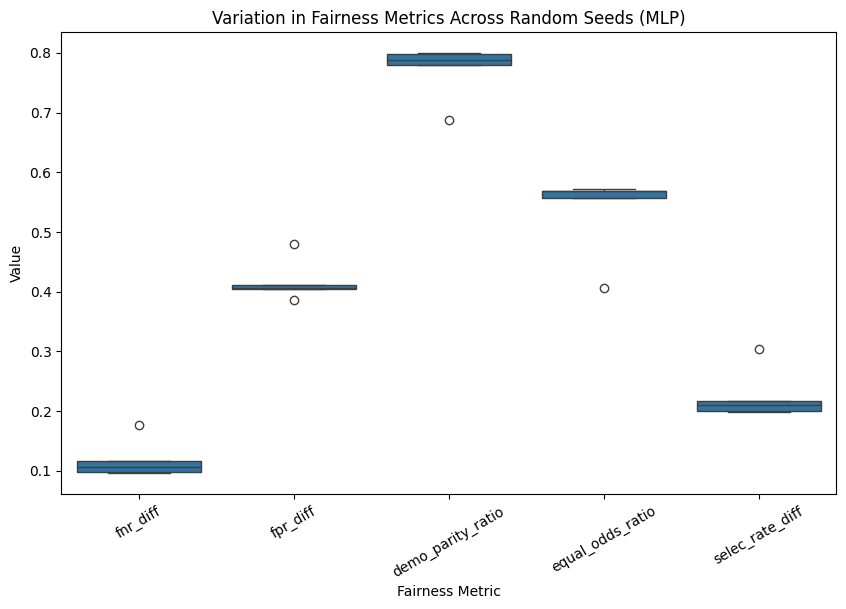

In [84]:
##@markdown TODO: Create boxplots to show variation in fairness metrics from just changing random seeds.
import seaborn as sns

metrics_long = results_df.melt(
    id_vars=['run'],
    value_vars=['fnr_diff', 'fpr_diff', 'demo_parity_ratio',
                'equal_odds_ratio', 'selec_rate_diff'],
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=metrics_long,
    x='metric',
    y='value'
)

plt.title("Variation in Fairness Metrics Across Random Seeds (MLP)")
plt.xlabel("Fairness Metric")
plt.ylabel("Value")

plt.xticks(rotation=30)
plt.show()

In [85]:
#@markdown TODO: train a train multi-layer perceptron while varying the train&test with a fixed random_state
results = []

for i in range(5):
  mlp_X_train, mlp_X_test, mlp_y_train, mlp_y_test = prepare_data(mlp_df, TEST_SET_FRACTION, i)

  mlp = MLPClassifier(random_state=42)
  mlp.fit(mlp_X_train, mlp_y_train)

  y_pred = mlp.predict(mlp_X_test)

  metrics = fairness_metrics(mlp_y_test, y_pred, race)
  metrics['run'] = i
  results.append(metrics)

results_df = pd.concat(results, ignore_index=True)

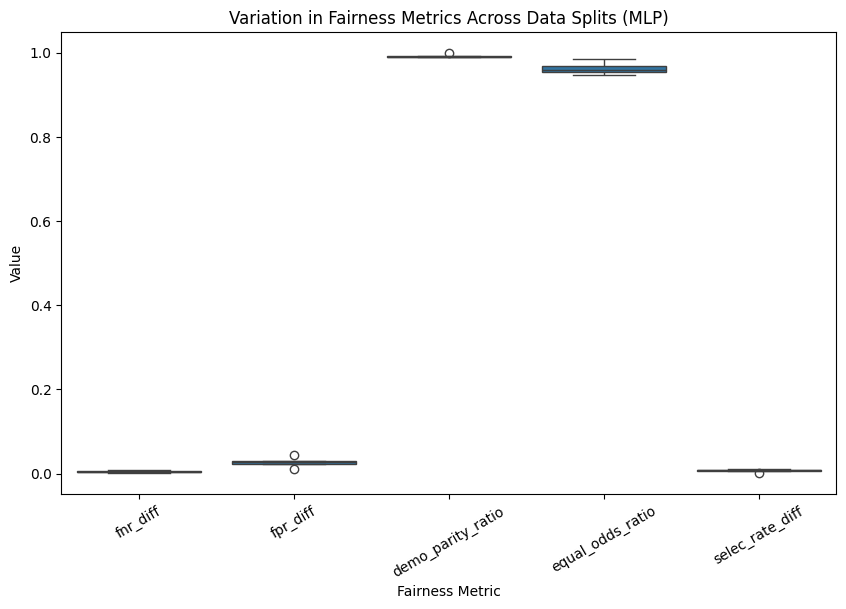

In [87]:
##@markdown TODO: Create boxplots to show variation in fairness metrics from just changing test-train splits.
metrics_long = results_df.melt(
    id_vars=['run'],
    value_vars=['fnr_diff', 'fpr_diff', 'demo_parity_ratio',
                'equal_odds_ratio', 'selec_rate_diff'],
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=metrics_long,
    x='metric',
    y='value'
)

plt.title("Variation in Fairness Metrics Across Data Splits (MLP)")
plt.xlabel("Fairness Metric")
plt.ylabel("Value")

plt.xticks(rotation=30)
plt.show()